In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

print(f"Keras backend set to: {keras.backend.backend()}")

Keras backend set to: jax


# Text Classification


---


**Learning Objectives for this chapter:**
- Understand how raw text is transformed into numbers (tokenization)
- Compare three tokenization strategies: character-level, word-level, and subword (BPE)
- Build and compare "bag of words" vs. sequence-based models
- Understand word embeddings and how to pretrain them with CBOW
- Apply these techniques to sentiment classification on the IMDb movie review dataset

---
## 📖 Text Classification



In this chapter, we will use the **IMDb movie review dataset**, where each review must be classified as positive (1) or negative (0) sentiment — a **binary classification** problem.

But before we can train any model, we need to answer a fundamental question: **how do we turn raw text into numbers that a neural network can process?**

---
##  Sets vs. Sequences — Two Approaches to Text

Once we can tokenize text, we have a fundamental modeling choice:

| Approach | Treats text as... | Captures word order? | Example model |
|---|---|---|---|
| **Set model** | Bag of tokens (order ignored) | ❌ No | Bag-of-words, TF-IDF |
| **Sequence model** | Ordered sequence | ✅ Yes | LSTM, Transformer |

**When do sets work well?** For many classification tasks, word *presence* is more important than word *order*. A review with the word "terrible" is likely negative, regardless of where it appears.

**When do sequences matter?** For tasks involving negation ("not bad"), syntax ("the dog bit the man" vs. "the man bit the dog"), or long-range dependencies.

We'll test both on the **IMDb dataset** and compare their performance.

### — Loading the IMDb Sentiment Dataset

The **IMDb Large Movie Review Dataset** contains 50,000 movie reviews labeled as positive or negative sentiment:
- 25,000 for training
- 25,000 for testing

We will:
1. Download and extract the dataset
2. Hold out 20% of training data as a **validation set** (for monitoring training progress)
3. Load everything into `tf.data.Dataset` pipelines using `text_dataset_from_directory`

In [ ]:
import os, pathlib, shutil, random
import keras

# Download and extract the IMDb tar.gz archive
# keras.utils.get_file caches it so subsequent runs skip the download
zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
# Inspect the directory structure
# Expect: train/pos, train/neg, test/pos, test/neg
# Each subdirectory contains .txt files, one review per file
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/root/.keras/datasets/imdb/aclImdb/train/pos
/root/.keras/datasets/imdb/aclImdb/train/neg
/root/.keras/datasets/imdb/aclImdb/train/unsup
/root/.keras/datasets/imdb/aclImdb/test/pos
/root/.keras/datasets/imdb/aclImdb/test/neg


In [ ]:
# Read a sample positive review to understand the data
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [ ]:
# Prepare the directory structure Keras expects:
# imdb_train/pos/ and imdb_train/neg/  ← 80% of original training data
# imdb_val/pos/   and imdb_val/neg/    ← 20% of original training data
# imdb_test/pos/  and imdb_test/neg/   ← original test data

train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

# Copy test set as-is
shutil.copytree(imdb_extract_dir / "test", test_dir)

val_percentage = 0.2  # Hold out 20% for validation
for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)  # Fixed seed for reproducibility
    num_val_samples = int(len(src_files) * val_percentage)

    # First 20% → validation
    os.makedirs(val_dir / category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)

    # Remaining 80% → training
    os.makedirs(train_dir / category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)

`text_dataset_from_directory` automatically:
- Reads all `.txt` files from subdirectories
- Uses the **subdirectory name** as the label (`neg` → 0, `pos` → 1)
- Batches the data for efficient training

In [ ]:
from keras.utils import text_dataset_from_directory

batch_size = 32  # Process 32 reviews at a time during training

train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds   = text_dataset_from_directory(val_dir,   batch_size=batch_size)
test_ds  = text_dataset_from_directory(test_dir,  batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


---
##  Set Models (Bag-of-Words)

###  Bag-of-Words (Unigrams)

The simplest text representation is a **bag of words**: a vector of size `|vocabulary|` where each dimension represents one token. We use **multi-hot encoding**: each position is `1` if the corresponding word appears in the document, `0` otherwise.

This completely ignores word order but captures *which* words appear — often sufficient for sentiment analysis.

**`TextVectorization` layer settings:**
- `max_tokens=20000`: keep the 20,000 most frequent words
- `split="whitespace"`: split on spaces
- `output_mode="multi_hot"`: binary vector output (1 if word present, 0 if absent)

The `.adapt()` call scans the training data to build the vocabulary — **never call adapt on validation or test data** (that would cause data leakage).

In [ ]:
from keras import layers

max_tokens = 20_000  # Keep the 20k most frequent words

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",  # Each input becomes a binary vector of size max_tokens
)

# Build the vocabulary from training data only (no labels needed for this step)
train_ds_no_labels = train_ds.map(lambda x, y: x)
text_vectorization.adapt(train_ds_no_labels)  # Scans training text, counts word frequencies

# Apply the vectorization layer to all three splits
# The lambda maps each (text, label) pair to (vector, label)
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

.as_numpy_iterator(): This method converts the tf.data.Dataset into a Python iterator that produces elements as NumPy arrays. TensorFlow datasets typically output TensorFlow tensors, but as_numpy_iterator() makes it easier to inspect or use with other Python libraries that expect NumPy arrays.

In [ ]:
# Check the shape of a batch of vectorized inputs
# Expected: (32, 20000) — 32 reviews, each represented as a 20,000-dim binary vector
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(32, 20000)

In [ ]:
# Labels shape: (32,) — one label (0 or 1) per review
y.shape

(32,)

###  Linear Classifier on Bag-of-Words

The bag-of-words vector feeds directly into a single **Dense layer** with a sigmoid activation — this is essentially **logistic regression**:

```
Input (20,000-dim) → Dense(1, sigmoid) → P(positive)
```

- **Sigmoid** activation outputs a value in (0, 1), which we interpret as the probability of positive sentiment
- **Binary crossentropy** loss is appropriate for binary classification
- **Early stopping** halts training when validation loss stops improving, preventing overfitting

In [ ]:
def build_linear_classifier(max_tokens, name):
    """Build a simple 1-layer linear model for binary text classification.

    Architecture: Input → Dense(1, sigmoid)
    This is logistic regression — the simplest possible neural network classifier.
    """
    inputs = keras.Input(shape=(max_tokens,))         # Input: a binary vector of size max_tokens
    outputs = layers.Dense(1, activation="sigmoid")(inputs)  # Output: probability in (0, 1)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",  # Standard loss for binary classification
        metrics=["accuracy"],
    )
    return model

model = build_linear_classifier(max_tokens, "bag_of_words_classifier")

In [ ]:
# Inspect the model — note the number of parameters:
# 20,000 weights (one per vocab word) + 1 bias = 20,001 parameters
model.summary(line_length=80)

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 20000)            │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 1)                │        20,001 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# EarlyStopping: stop training if val_loss doesn't improve for 2 consecutive epochs
# restore_best_weights=True: roll back to the best epoch's weights when done
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,  # Wait 2 epochs without improvement before stopping
)
history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8394 - loss: 0.4599 - val_accuracy: 0.8834 - val_loss: 0.3558
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9070 - loss: 0.2956 - val_accuracy: 0.8926 - val_loss: 0.3011
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9269 - loss: 0.2379 - val_accuracy: 0.8968 - val_loss: 0.2783
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9404 - loss: 0.2024 - val_accuracy: 0.8986 - val_loss: 0.2661
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9495 - loss: 0.1770 - val_accuracy: 0.9004 - val_loss: 0.2594
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9583 - loss: 0.1570 - val_accuracy: 0.8988 - val_loss: 0.2560
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9651 - loss: 0.1408 - val_accuracy: 0.8988 - val_loss: 0.2545
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9704 - loss: 0.1271 - val_accuracy: 0.

Plot training vs. validation accuracy to check for overfitting. A large gap between the two curves indicates overfitting.

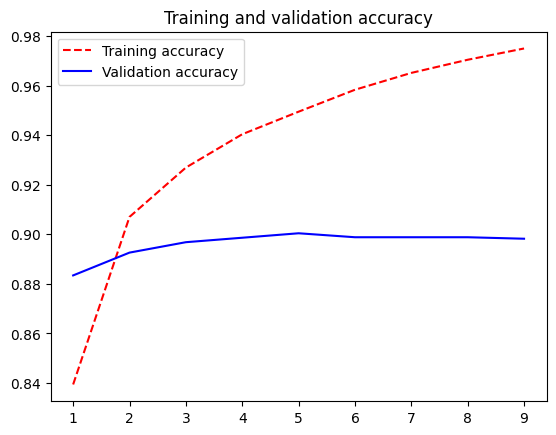

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

We can see that validation performance levels off rather than significantly declining; our model is so simple it cannot really overfit

In [ ]:
# Evaluate on the held-out test set — this is our unbiased performance estimate
# Expect around 87-89% accuracy for a bag-of-words linear model on IMDb
test_loss, test_acc = model.evaluate(bag_of_words_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8864 - loss: 0.2827


0.8863999843597412

### Bigram Model

A **bigram** is a pair of consecutive words (e.g., `"not good"`, `"highly recommended"`). Adding bigrams to our bag-of-words captures some local word-order information that unigrams miss.

For example, `"not good"` has a very different sentiment from `"good"` alone.

We enable bigrams by setting `ngrams=2` in `TextVectorization`. This adds bigram entries to the vocabulary on top of unigrams, so we increase `max_tokens` to 30,000 to accommodate them.

In [ ]:
max_tokens = 30_000  # Larger vocabulary to fit both unigrams and bigrams

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,  # Include all unigrams AND bigrams (consecutive word pairs)
)
text_vectorization.adapt(train_ds_no_labels)

bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [ ]:
# Shape is now (32, 30000) — larger vector to hold bigram features too
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [ ]:
# Inspect part of the vocabulary — you should see bigrams like 'the movie' or 'is great'
# among the word-pair entries
text_vectorization.get_vocabulary()[100:108]

[np.str_('how'),
 np.str_('most'),
 np.str_('him'),
 np.str_('dont'),
 np.str_('it was'),
 np.str_('made'),
 np.str_('one of'),
 np.str_('for the')]

In [ ]:
# Train the same linear architecture on bigram features
# Bigrams should outperform unigrams because they capture negation and common phrases
model = build_linear_classifier(max_tokens, "bigram_classifier")
model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8641 - loss: 0.4006 - val_accuracy: 0.8956 - val_loss: 0.3010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9347 - loss: 0.2248 - val_accuracy: 0.9008 - val_loss: 0.2605


In [ ]:
# Compare this accuracy to the unigram model — expect a small improvement
test_loss, test_acc = model.evaluate(bigram_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8953 - loss: 0.3092


0.8952800035476685

---
## Sequence Models

Set models discard word order. To preserve it, we switch to **sequence models** that process text as an **ordered list of token IDs**.

For this, we change `TextVectorization` to:
- `output_mode="int"`: output integer token IDs (not a binary vector)
- `output_sequence_length=600`: pad or truncate all sequences to exactly 600 tokens

The result is a matrix of shape `(batch_size, 600)` where each row is a padded sequence of token indices.

In [ ]:
max_length = 600   # Truncate/pad all reviews to 600 words
max_tokens = 30_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",            # Output integer token IDs, not binary vectors
    output_sequence_length=max_length,  # Fixed-length sequences (pad with 0s if shorter)
)
text_vectorization.adapt(train_ds_no_labels)

sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [ ]:
# Shape: (32, 600) — 32 reviews, each a sequence of 600 token IDs
# Compare to bag-of-words: (32, 20000) — very different representation!
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(32, 600)

In [ ]:
# Inspect raw token ID sequences
# You'll see integers (word IDs) and trailing 0s (padding for shorter reviews)
x

array([[1614,    1,    1, ...,    0,    0,    0],
       [  10,  112,    2, ...,    0,    0,    0],
       [  54,   55,  696, ...,    0,    0,    0],
       ...,
       [  30,  175,  604, ...,    0,    0,    0],
       [   2, 1544,  135, ...,    0,    0,    0],
       [ 587,   72,   66, ...,    0,    0,    0]])

### — LSTM with One-Hot Encoding

Our first sequence model uses a **Bidirectional LSTM** (Long Short-Term Memory network).

**One-hot encoding** converts each integer token ID into a sparse binary vector of size `max_tokens`. For token ID 42 in a vocabulary of 30,000, the vector has a `1` at position 42 and `0` everywhere else.

A custom `OneHotEncoding` layer is used because Keras's built-in one-hot is limited. It works by:
1. Creating an identity matrix of shape `(max_tokens, max_tokens)`
2. Looking up each token ID as a row index

The architecture:
```
Input (batch, 600) → OneHot (batch, 600, 30000) → BiLSTM(64) → Dropout(0.5) → Dense(1, sigmoid)
```

> ⚠️ **Note:** This model may be slow or may error on TensorFlow due to a known bug. If so, use the JAX or PyTorch backend.

ops.take is essentially fancy indexing — it lets you pick rows out of a matrix using a list of indices.
matrix = [[1, 0, 0],   # row 0
          [0, 1, 0],   # row 1
          [0, 0, 1]]   # row 2

indices = [2, 0, 1, 2]   # which rows to grab

ops.take(matrix, indices, axis=0)

 Result:

[[0, 0, 1],   ← row 2

[1, 0, 0],   ← row 0

[0, 1, 0],   ← row 1

[0, 0, 1]]   ← row 2 again

In [ ]:
from keras import ops

class OneHotEncoding(keras.Layer):
    """Custom Keras layer that converts integer token IDs to one-hot vectors.

    For vocabulary size V and sequence length T:
    Input shape:  (batch, T)      — integer token IDs
    Output shape: (batch, T, V)   — one-hot vectors
    """
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth  # Vocabulary size

    def call(self, inputs):
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])  # Flatten to 1D
        one_hot_vectors = ops.eye(self.depth)                     # Identity matrix (V × V)
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)  # Look up each token
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))  # Restore batch dims

one_hot_encoding = OneHotEncoding(max_tokens)

In [ ]:
# Verify the output shape: (32, 600, 30000)
# This is a very large tensor — 32 × 600 × 30,000 = 576 million values!
# One-hot encoding is memory-inefficient; embeddings (next section) solve this.
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

(32, 600, 30000)

In [ ]:
hidden_dim = 64  # LSTM hidden state size

inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)                         # (batch, 600, 30000)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x) # (batch, 128) — concat of forward and backward
x = layers.Dropout(0.5)(x)                          # Regularization: randomly zero 50% of units
outputs = layers.Dense(1, activation="sigmoid")(x)   # (batch, 1) — sentiment probability
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
# Note the parameter count vs. the linear model — much larger!
# The BiLSTM has 4 gate matrices per direction × 2 directions × hidden_dim
model.summary(line_length=80)

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 600)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ one_hot_encoding (OneHotEncoding) │ (None, 600, 30000)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)     │ (None, 128)              │    15,393,280 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 1)                │           129 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ⚠️NOTE⚠️: The following fit call will error on a T4 GPU on the TensorFlow
# backend due to a bug in TensorFlow. If you the follow cell errors out,
# do one of the following:
# - Skip the following two cells.
# - Switch to the Jax or Torch backend and re-run this notebook.
# - Change the GPU type in your runtime (requires Colab Pro as of this writing).

In [ ]:
# This will be significantly slower than the bag-of-words model
# because LSTMs process sequences step by step (sequential, not parallelizable)
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 691s 1s/step - accuracy: 0.6642 - loss: 0.6024 - val_accuracy: 0.8542 - val_loss: 0.3619
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.8686 - loss: 0.3405 - val_accuracy: 0.8600 - val_loss: 0.3474


In [ ]:
# Does the LSTM beat the bag-of-words model despite being more complex?
# (Often not by much on IMDb — word order matters less than word identity here)
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 210s 269ms/step - accuracy: 0.8323 - loss: 0.3906


0.832319974899292

This model works, but it trains very slowly, especially compared to the lightweight model of the previous section. That’s because our inputs are quite large: each input sample is encoded as a matrix of size (600, 30000) (600 words per sample, 30,000 possible words). That is 18,000,000 floating-point numbers for a single movie review! Our bidirectional LSTM has a lot of work to do. In addition to being slow, the model only gets to 82% test accuracy — it doesn’t perform nearly as well as our very fast set-based models.

Clearly, using one-hot encoding to turn words into vectors, which was the simplest thing we could do, wasn’t a great idea.

---
### — LSTM with Word Embeddings (Learned)

One-hot vectors are **sparse** (mostly zeros) and **high-dimensional** (30,000-dim). They also treat every word as equidistant — there's no notion that `"king"` and `"queen"` are more similar than `"king"` and `"bicycle"`.

**Word embeddings** solve this with a dense, low-dimensional representation. An `Embedding` layer is a learned lookup table:
- Input: integer token ID (e.g., 42)
- Output: a `hidden_dim`-dimensional dense vector (e.g., 64 floats)

The embedding vectors are **trained jointly** with the rest of the model, so they automatically learn to encode semantic similarity.

**Memory comparison:**
- One-hot: `600 × 30,000 = 18M` values per batch item
- Embedding: `600 × 64 = 38K` values per batch item — **470× more efficient**

The `mask_zero=True` argument tells downstream layers to ignore padded positions (token ID 0 = padding).

In [ ]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=max_tokens,   # Vocabulary size — number of rows in the lookup table
    output_dim=hidden_dim,  # Embedding dimension — how many floats per word
    mask_zero=True,         # Mask out padding tokens (ID=0) from LSTM computation
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x) # outputs a vector of 128 numbers
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="softmax")(x) #in the book its a type and says sigmoid but that is for categorical, this is multiclass
model = keras.Model(inputs, outputs, name="lstm_with_embedding")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
# The Embedding layer has max_tokens * hidden_dim = 30,000 * 64 = 1.92M parameters
# But the model is MUCH faster than one-hot because the embedding reduces dimensionality first
model.summary(line_length=80)

Model: "lstm_with_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3         │ (None, 600)       │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, 600, 64)   │   1,920,000 │ input_layer_3[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, 600)       │           0 │ input_layer_3[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional_1       │ (None, 128)       │      66,048 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_1 (Dropout)   │ (None, 128)       │           0 │ bidirectional_1[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_3 (Dense)       │ (None, 1)         │         129 │ dropout_1[0][0]    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 1,986,177 (7.58 MB)

 Trainable params: 1,986,177 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Expect this to be faster than the one-hot LSTM and achieve similar or better accuracy
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.7853 - loss: 0.4518 - val_accuracy: 0.8698 - val_loss: 0.3272
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9132 - loss: 0.2260 - val_accuracy: 0.8660 - val_loss: 0.3322
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8594 - loss: 0.3444


0.8594399690628052

---
### — Pretraining Word Embeddings with CBOW

So far the Embedding layer was **randomly initialized** and trained from scratch using only the sentiment labels. But what if we could start with better embeddings that already encode semantic meaning?

**CBOW (Continuous Bag-Of-Words)** is a self-supervised method to pretrain embeddings:
- Given the **surrounding context words**, predict the **center word**
- For a context window of size 4: `[w₁, w₂, _, w₄, w₅]` → predict `w₃`
- No labels needed — the task is created from the text structure itself

This forces the model to learn that words appearing in similar contexts have similar embeddings — this is why `"king"` and `"queen"` end up close in embedding space.

**Preprocessing pipeline:**
1. Tokenize each review (no padding — variable length for CBOW)
2. Slide a window of size 9 (4 left + center + 4 right) over each sequence
3. Split each window into: context (8 surrounding words) and label (center word)

This creates a massive self-supervised dataset from unlabeled text.

In [ ]:
# Create a tokenizer that uses the same vocabulary as our classifier (no padding)
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
    # No output_sequence_length — sequences remain variable length for CBOW
)

#Preprocessing our IMDb data for pretraining a CBOW model
To preprocess our data, we will slide a window across our training data, creating “bags” of nine consecutive tokens. Then, we use the middle word as our label and the remaining eight words as an unordered context to predict our label.



In [ ]:
import tensorflow as tf

context_size = 4  # Use 4 words before and 4 words after the center word
window_size = 9   # Total window: 4 + 1 (center) + 4 = 9 tokens

def window_data(token_ids):
    """Slide a window of size 9 over a tokenized sequence.

    For a sequence of N tokens, creates N-8 windows (to have full context on both sides).
    Returns a dataset of windows, each a tensor of shape (9,).
    """
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]           # Shape: (1, 9)
    windows = windows + tf.range(num_windows)[:, None] # Broadcast to (N-8, 9)
    windowed_tokens = tf.gather(token_ids, windows)    # Look up actual token IDs
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    """Split a 9-token window into CBOW input (context) and target (center word).

    Input:  [w0, w1, w2, w3, CENTER, w5, w6, w7, w8]
    Output: bag = [w0, w1, w2, w3, w5, w6, w7, w8], label = CENTER
    """
    left = window[:context_size]          # 4 words before center
    right = window[context_size + 1 :]   # 4 words after center
    bag = tf.concat((left, right), axis=0)  # All 8 context words
    label = window[4]                    # Center word = prediction target
    return bag, label

# Build the CBOW training dataset from the IMDb training corpus (ignoring labels)
dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)          # Strip labels
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)     # Tokenize
#interleave does two things simultaneously:
#Applies window_data to each review → produces a mini-dataset of windows per review
#Flattens all those mini-datasets into one single stream of windows
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)  # Extract windows
dataset = dataset.map(split_label, num_parallel_calls=8)             # Split into (context, center)

Found 75000 files belonging to 3 classes.


**CBOW Model Architecture:**
- Takes 8 context word IDs as input
- Embeds them into 64-dim vectors
- Averages the 8 embeddings (`GlobalAveragePooling1D`) — this is the "bag" in CBOW
- Predicts which word belongs in the center using a Dense(vocab_size) output

The learned embeddings in `cbow_embedding` will capture semantic relationships after training.

In [ ]:
hidden_dim = 64

# Input: 8 context word IDs (2 * context_size = 2 * 4 = 8)
inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = layers.Embedding(
    max_tokens,  # input_dim: vocabulary size
    hidden_dim,  # output_dim: embedding dimensionality
)  # Shape: (batch, 8, 64)
x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)  # Average 8 context embeddings → (batch, 64)
outputs = layers.Dense(max_tokens, activation="sigmoid")(x)  # Predict center word
cbow_model = keras.Model(inputs, outputs)
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # Target is an integer class index
    metrics=["sparse_categorical_accuracy"],
)

In [ ]:
cbow_model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)        │ (None, 8)                │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ embedding_1 (Embedding)           │ (None, 8, 64)            │     1,920,000 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling1d          │ (None, 64)               │             0 │
│ (GlobalAveragePooling1D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_4 (Dense)                   │ (None, 30000)            │     1,950,000 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 3,870,000 (14.76 MB)

 Trainable params: 3,870,000 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CBOW for 4 epochs on large batches (1024 windows at a time)
# .cache() keeps the preprocessed dataset in memory to speed up training
# After training, cbow_embedding.embeddings contains semantically meaningful vectors
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=4)

Epoch 1/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 468s 28ms/step - loss: 6.5587 - sparse_categorical_accuracy: 0.0463
Epoch 2/4
   13/16503 ━━━━━━━━━━━━━━━━━━━━ 3:02 11ms/step - loss: 6.0638 - sparse_categorical_accuracy: 0.1050

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 188s 11ms/step - loss: 5.9300 - sparse_categorical_accuracy: 0.1159
Epoch 3/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 187s 11ms/step - loss: 5.7684 - sparse_categorical_accuracy: 0.1255
Epoch 4/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 188s 11ms/step - loss: 5.6897 - sparse_categorical_accuracy: 0.1283


### — Using the CBOW Pretrained Embeddings for Sentiment Classification

Now we **transfer** the pretrained CBOW embeddings into our sentiment classifier.

The architecture is the same as before (BiLSTM + Dropout + Dense), but instead of random initialization, the Embedding layer starts with the CBOW-pretrained weights. This is a form of **transfer learning** within the same domain.

The key line: `lstm_embedding.embeddings.assign(cbow_embedding.embeddings)` copies the weights from the CBOW model into the classification model's embedding layer.

**Why does this help?** The CBOW training used all 25,000 reviews to learn word semantics, but the sentiment classifier only gets gradient signal from the 0/1 labels. Starting from semantically meaningful embeddings gives the model a better initialization and can improve accuracy — especially with limited labeled data.

In [ ]:
# Build the same BiLSTM classifier as before
# lstm_embedding is defined as a standalone variable so we can set its weights below
inputs = keras.Input(shape=(max_length,))
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x) #this should be sigmoid because it is the last stage of the process (binary classification)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [ ]:
# Transfer pretrained weights from CBOW into the classification model's embedding layer
# After this line, lstm_embedding starts with semantically-rich initializations
# instead of random values
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

Array([[ 0.01295206, -0.00474935,  0.01958878, ..., -0.02355227,
        -0.04622463,  0.04998723],
       [ 0.70207363,  0.4984389 ,  0.36413154, ...,  0.3700997 ,
        -0.6842203 , -0.25461635],
       [ 0.48781732,  0.43168834, -0.6915068 , ...,  1.0221386 ,
        -1.5324092 , -0.10406701],
       ...,
       [ 0.48727018, -0.6346368 ,  0.0233351 , ..., -0.26969495,
        -0.2151338 , -0.3225071 ],
       [ 0.3465501 ,  0.12543601,  0.36898968, ...,  0.16540022,
        -0.16763921, -0.40531605],
       [ 0.17148148,  0.1948455 ,  0.5899499 , ...,  0.27276006,
         0.05524073, -0.46913928]], dtype=float32)

In [ ]:
# Train the classifier — compare final test accuracy to the randomly-initialized embedding model
# The CBOW-pretrained embeddings should give a small but consistent accuracy boost
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.7751 - loss: 0.4748 - val_accuracy: 0.8546 - val_loss: 0.3476
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.8275 - loss: 0.4083 - val_accuracy: 0.8570 - val_loss: 0.3427


In [ ]:
# Final evaluation — compare to all previous models:
# Bag-of-words unigram (~88%), bigram (~89%), LSTM one-hot, LSTM embedding, LSTM + CBOW
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8458 - loss: 0.3611


0.8458399772644043

---
## 📊 Summary: Model Comparison

| Model | Representation | Captures order? | Expected Test Acc. |
|---|---|---|---|
| Bag-of-words (unigram) | Multi-hot vector | ❌ | ~88% |
| Bag-of-words (bigram)  | Multi-hot + bigrams | Partially | ~89% |
| BiLSTM + One-hot       | Integer sequence | ✅ | ~85-88% |
| BiLSTM + Embedding     | Dense sequence  | ✅ | ~87-90% |
| BiLSTM + CBOW pretrain | Pretrained dense sequence | ✅ | ~88-91% |

**Key takeaway:** For sentiment analysis on IMDb, bag-of-words models are competitive with sequence models because *which* words appear matters more than *order*. The real advantage of sequence models shows up on tasks requiring syntactic or long-range reasoning.